In [1]:
%matplotlib inline

In [2]:
%autosave 300

Autosaving every 300 seconds


# Load Dataset

In [1]:
import torch
import torchvision
from torchvision.transforms import v2
from torch.utils.data import random_split

transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

train_transform = v2.Compose([
    v2.RandomAffine(
        degrees=6,                       # rotation_range=15
        translate=(0.08, 0.08),           # width_shift_range & height_shift_range=0.12
        scale=(0.9, 1.1),                 # zoom_range=0.1 (0.9x hingga 1.1x)
        shear=8                          # shear_range=10
    ),
    v2.RandomHorizontalFlip(p=0.5),       # horizontal_flip=True
    v2.ColorJitter(
        brightness=(0.9, 1.1),            # brightness_range=[0.9, 1.1]
        hue=(-0.05, 0.05)                 # Mendekati channel_shift_range (perubahan warna)
    ),
    v2.ToImage(),                         # Konversi PIL Image/Array ke Tensor
    v2.ToDtype(torch.float32, scale=True),# Ubah piksel [0-255] ke range [0.0, 1.0]
    v2.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

batch_size = 32

full_trainset = torchvision.datasets.CIFAR10(root='../data', train=True, download=False,transform=transform)
train_size = int(0.9 * len(full_trainset))
val_size = len(full_trainset) - train_size
trainset, valset = random_split(full_trainset, [train_size, val_size])
valset.dataset.transform = transform  

trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)
valloader = torch.utils.data.DataLoader(valset, batch_size=batch_size,
                                        shuffle=False, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='../data', train=False,
                                       download=False, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

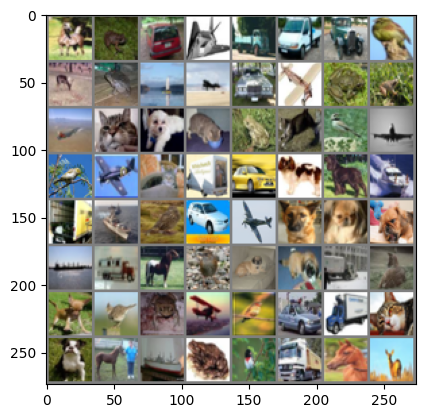

horse frog  car   plane truck truck car   bird  deer  frog  ship  plane car   plane frog  frog  plane cat   dog   cat   frog  cat   bird  plane bird  plane cat   truck car   dog   dog   ship  truck ship  bird  car   plane dog   dog   dog   ship  truck horse bird  dog   dog   truck deer  dog   bird  frog  plane bird  car   truck cat   dog   horse ship  frog  bird  truck horse deer 


In [4]:
import matplotlib.pyplot as plt
import numpy as np

def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# show some training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images))
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

# Model Architecture

## Kaggle

In [2]:
import torch
import torch.nn as nn

class CustomCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(CustomCNN, self).__init__()
        
        # Block 1 (Filters: 32)
        # Input shape CIFAR-10: (3, 32, 32) -> in_channels=3
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(p=0.2)
        )
        
        # Block 2 (Filters: 64)
        self.block2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(p=0.3)
        )
        
        # Block 3 (Filters: 128)
        self.block3 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(p=0.4)
        )
        
        # Block 4 (Filters: 256)
        self.block4 = nn.Sequential(
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(p=0.5)
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 2 * 2, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.classifier(x)
        return x

# Inisialisasi model dan pindahkan ke GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
net = CustomCNN(num_classes=10).to(device)

## Original

In [2]:
import torch.nn as nn
import torch.nn.functional as F


class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


net = Net()

# Training

In [3]:
import torch

class EarlyStopping:
    def __init__(self, patience=5, delta=0.0, path='best_model.pth'):
        """
        Args:
            patience (int): Berapa epoch menunggu tanpa peningkatan sebelum stop.
            delta (float): Perubahan minimum loss yang dianggap sebagai peningkatan.
            path (str): Lokasi penyimpanan checkpoint model terbaik.
        """
        self.patience = patience
        self.delta = delta
        self.path = path
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        elif val_loss > self.best_loss - self.delta:
            self.counter += 1
            print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.save_checkpoint(model)
            self.counter = 0

    def save_checkpoint(self, model):
        """Menyimpan model ketika loss validasi menurun."""
        torch.save(model.state_dict(), self.path)

In [6]:
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
net.to(device)
criterion = nn.CrossEntropyLoss().to(device)
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)
print(device)

scheduler = ReduceLROnPlateau(
    optimizer, 
    mode='min',        # 'min' untuk memantau loss (mencari nilai terkecil)
    factor=0.5,        # LR baru = LR lama * 0.1
    patience=10,
    verbose=True       # Tampilkan notifikasi saat LR diturunkan
)

early_stopping = EarlyStopping(patience=40, path='best_cifar10_model.pth')


cuda


Epoch [1/300] | Train Loss: 1.1707 - Train Acc: 58.51% | Val Loss: 1.2124 - Val Acc: 57.20%
Epoch [2/300] | Train Loss: 1.1223 - Train Acc: 60.25% | Val Loss: 1.2199 - Val Acc: 56.88%
EarlyStopping counter: 1 out of 40
Epoch [3/300] | Train Loss: 1.0977 - Train Acc: 61.13% | Val Loss: 1.1837 - Val Acc: 58.04%
Epoch [4/300] | Train Loss: 1.0710 - Train Acc: 61.93% | Val Loss: 1.1680 - Val Acc: 59.48%
Epoch [5/300] | Train Loss: 1.0450 - Train Acc: 63.26% | Val Loss: 1.1495 - Val Acc: 59.24%
Epoch [6/300] | Train Loss: 1.0233 - Train Acc: 63.99% | Val Loss: 1.2185 - Val Acc: 58.34%
EarlyStopping counter: 1 out of 40
Epoch [7/300] | Train Loss: 1.0061 - Train Acc: 64.52% | Val Loss: 1.1469 - Val Acc: 59.74%
Epoch [8/300] | Train Loss: 0.9845 - Train Acc: 65.51% | Val Loss: 1.1456 - Val Acc: 59.50%
Epoch [9/300] | Train Loss: 0.9636 - Train Acc: 66.05% | Val Loss: 1.1255 - Val Acc: 60.54%
Epoch [10/300] | Train Loss: 0.9467 - Train Acc: 66.60% | Val Loss: 1.1331 - Val Acc: 60.98%
EarlyStop

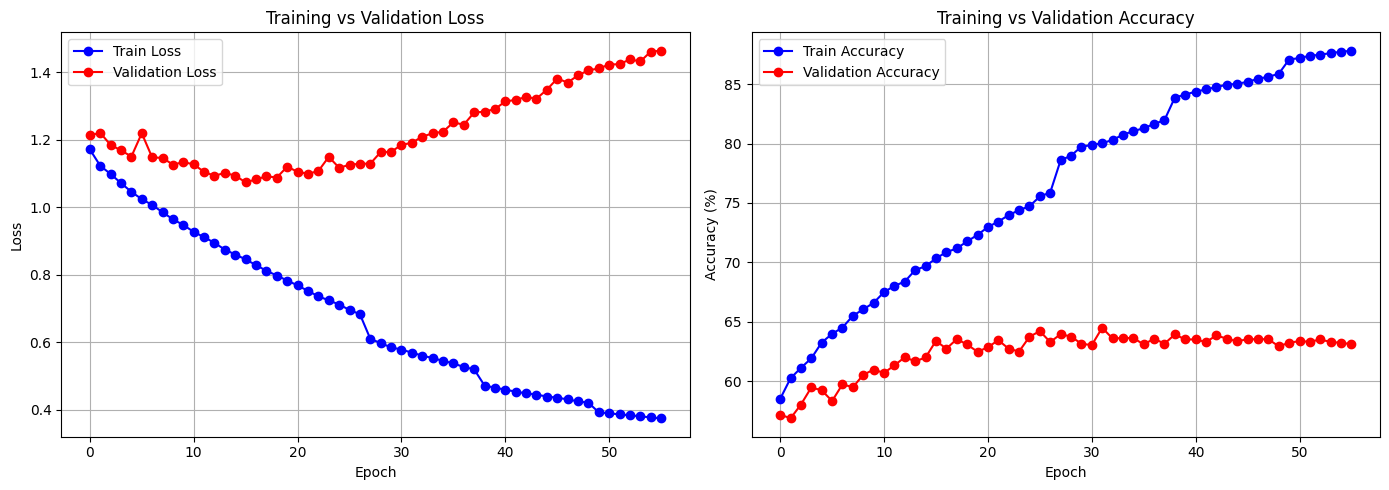

In [7]:
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

epochs = 300

for epoch in range(epochs):
    net.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for i, data in enumerate(trainloader, 0):
        inputs, labels = data[0].to(device), data[1].to(device)
        labels = F.one_hot(labels, num_classes=10).float().to(device)

        optimizer.zero_grad()

        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        
        target_labels = torch.argmax(labels, dim=1) if labels.ndim > 1 else labels
        
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == target_labels).sum().item()

    epoch_train_loss = running_loss / len(trainloader.dataset)
    epoch_train_acc = 100 * correct_train / total_train
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)

    net.eval()  
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad(): 
        for data in valloader:
            inputs, labels = data[0].to(device), data[1].to(device)
            labels = F.one_hot(labels, num_classes=10).float().to(device)

            outputs = net(inputs)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * inputs.size(0)
            
            target_labels = torch.argmax(labels, dim=1) if labels.ndim > 1 else labels
            
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == target_labels).sum().item()

    epoch_val_loss = running_val_loss / len(valloader.dataset)
    epoch_val_acc = 100 * correct_val / total_val
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    print(f"Epoch [{epoch + 1}/{epochs}] | "
          f"Train Loss: {epoch_train_loss:.4f} - Train Acc: {epoch_train_acc:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f} - Val Acc: {epoch_val_acc:.2f}%")

    scheduler.step(epoch_val_loss)

    # Cek kriteria Early Stopping
    early_stopping(epoch_val_loss, net)

    # Hentikan loop training jika early stopping terdeteksi
    if early_stopping.early_stop:
        print("Early stopping triggered! Training dihentikan.")
        break

print('Finished Training')

epochs_range = range(1, epochs + 1)

plt.figure(figsize=(14, 5))

# Grafik Loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', color='blue', marker='o')
plt.plot(val_losses, label='Validation Loss', color='red', marker='o')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Grafik Akurasi
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy', color='blue', marker='o')
plt.plot(val_accuracies, label='Validation Accuracy', color='red', marker='o')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Save Weight


In [ ]:
PATH = '../weight/cifar_net.pt'
torch.save(net.state_dict(), PATH)

# Hyperparameter Tunning

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision.transforms import v2
from torch.utils.data import DataLoader, random_split
import optuna

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ==========================================
# 1. DEFINE OBJECTIVE FUNCTION FOR OPTUNA
# ==========================================
def objective(trial):
    # --- A. HYPERPARAMETERS TO TUNE ---
    
    # 1. Data Augmentation Parameters
    rot_degree = trial.suggest_int('rot_degree', 0, 30)
    translate_val = trial.suggest_float('translate_val', 0.0, 0.2)
    shear_val = trial.suggest_int('shear_val', 0, 20)
    flip_prob = trial.suggest_float('flip_prob', 0.0, 0.8)
    brightness_val = trial.suggest_float('brightness_val', 0.8, 1.2)
    
    # 2. Training Parameters
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])

    # --- B. TRANSFORMS & DATASET ---
    train_transform = v2.Compose([
        v2.RandomAffine(
            degrees=rot_degree, 
            translate=(translate_val, translate_val), 
            shear=shear_val
        ),
        v2.RandomHorizontalFlip(p=flip_prob),
        v2.ColorJitter(brightness=(min(brightness_val, 2.0 - brightness_val), max(brightness_val, 2.0 - brightness_val))),
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

    val_transform = v2.Compose([
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

    # Load CIFAR-10 Dataset
    full_trainset = torchvision.datasets.CIFAR10(
        root='../data', train=True, download=False, transform=train_transform
    )
    
    # Split Train & Validation (80:20)
    train_size = int(0.8 * len(full_trainset))
    val_size = len(full_trainset) - train_size
    trainset, valset = random_split(full_trainset, [train_size, val_size])
    valset.dataset.transform = val_transform

    trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
    valloader = DataLoader(valset, batch_size=batch_size, shuffle=False, num_workers=2)

    # --- C. MODEL, LOSS, OPTIMIZER ---
    # Menggunakan model CustomCNN Anda sebelumnya
    net = CustomCNN(num_classes=10).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(net.parameters(), lr=lr, weight_decay=weight_decay)

    # --- D. TRAINING & VALIDATION LOOP (Pilihan singkat: 5 epoch per trial) ---
    epochs = 15
    for epoch in range(epochs):
        # Training Phase
        net.train()
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = net(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        # Validation Phase
        net.eval()
        running_val_loss = 0.0
        correct_val = 0
        total_val = 0
        with torch.no_grad():
            for inputs, labels in valloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = net(inputs)
                loss = criterion(outputs, labels)
                
                running_val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        epoch_val_loss = running_val_loss / len(valloader.dataset)
        epoch_val_acc = 100 * correct_val / total_val

        # --- E. OPTUNA PRUNING (Menghentikan trial jelek lebih awal) ---
        trial.report(epoch_val_acc, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    # Optuna akan memaksimalkan nilai evaluasi akhir (Validation Accuracy)
    return epoch_val_acc


# ==========================================
# 2. RUN OPTUNA STUDY
# ==========================================
if __name__ == '__main__':
    # Pastikan optuna sudah di-install: pip install optuna
    
    # Buat study dengan objective 'maximize' (karena kita mengoptimalkan Akurasi Validasi)
    study = optuna.create_study(
        direction="maximize",
        pruner=optuna.pruners.MedianPruner() # Mengabaikan trial jelek secara otomatis
    )
    
    # Jalankan tuning sebanyak 20 trial (sesuaikan n_trials dengan kapasitas waktu Anda)
    study.optimize(objective, n_trials=20)

    # Print Hasil Terbaik
    print("\n" + "="*40)
    print("HYPERPARAMETER TUNING SELESAI!")
    print("="*40)
    print(f"Akurasi Validasi Terbaik: {study.best_value:.2f}%")
    print("Hyperparameter Terbaik:")
    for key, value in study.best_params.items():
        print(f"  - {key}: {value}")

[I 2026-09-27 18:06:50,827] A new study created in memory with name: no-name-de9f43c8-bf56-4ceb-9835-2687e6b10896
[I 2026-09-27 18:07:24,887] Trial 0 finished with value: 81.16 and parameters: {'rot_degree': 5, 'translate_val': 0.18354882829801633, 'shear_val': 4, 'flip_prob': 0.577071339749278, 'brightness_val': 0.8509859398665145, 'lr': 0.003765193351959873, 'weight_decay': 6.131829402811328e-05, 'batch_size': 64}. Best is trial 0 with value: 81.16.
[I 2026-09-27 18:08:10,711] Trial 1 finished with value: 81.29 and parameters: {'rot_degree': 9, 'translate_val': 0.13662113812841872, 'shear_val': 4, 'flip_prob': 0.2122519828774089, 'brightness_val': 0.9117283087240127, 'lr': 0.0012500653727277, 'weight_decay': 0.0001753086953252743, 'batch_size': 32}. Best is trial 1 with value: 81.29.
[I 2026-09-27 18:08:44,415] Trial 2 finished with value: 83.73 and parameters: {'rot_degree': 19, 'translate_val': 0.12966017102179384, 'shear_val': 1, 'flip_prob': 0.6057833298750348, 'brightness_val': 


HYPERPARAMETER TUNING SELESAI!
Akurasi Validasi Terbaik: 85.23%
Hyperparameter Terbaik:
  - rot_degree: 6
  - translate_val: 0.08988529129507355
  - shear_val: 8
  - flip_prob: 0.07782251879907326
  - brightness_val: 1.112435238690792
  - lr: 0.0007096141997015271
  - weight_decay: 2.8394054709378845e-05
  - batch_size: 32


In [ ]:
best_params = study.best_params

# Contoh penerapan langsung
best_lr = best_params['lr']
best_batch_size = best_params['batch_size']
best_rot_degree = best_params['rot_degree']

print(f"Gunakan Learning Rate ini untuk training utama: {best_lr}")

# Testing

In [ ]:
PATH = '../weight/cifar_net.pt'
net = Net()
net.load_state_dict(torch.load(PATH, weights_only=True))

In [10]:
dataiter = iter(testloader)
images, labels = next(dataiter)

# print images
# imshow(torchvision.utils.make_grid(images))
print('GroundTruth: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))

GroundTruth:  cat   ship  ship  plane


## Test on 1 batch

In [ ]:
outputs = net(images)

In [ ]:
_, predicted = torch.max(outputs, 1)

print('Predicted: ', ' '.join(f'{classes[predicted[j]]:5s}'
                              for j in range(4)))

## Test on the whole test data

In [ ]:
# prepare to count predictions for each class
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}
correct = 0
total = 0

# again no gradients needed
with torch.no_grad():
    for data in testloader:
        images, labels = data[0].to(device), data[1].to(device)
        labels = F.one_hot(labels, num_classes=10).float().to(device)
        outputs = net(images)
        target_labels = torch.argmax(labels, dim=1) if labels.ndim > 1 else labels
        _, predictions = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predictions == target_labels).sum().item()
        # collect the correct predictions for each class
        for label, prediction in zip(target_labels, predictions):
            if label == prediction:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1


# print accuracy for each class
for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

print(f'Accuracy of the network on the 10000 test images: {100 * correct / total:.1f} %')

Accuracy for class: plane is 91.1 %
Accuracy for class: car   is 95.0 %
Accuracy for class: bird  is 81.5 %
Accuracy for class: cat   is 75.0 %
Accuracy for class: deer  is 88.9 %
Accuracy for class: dog   is 85.1 %
Accuracy for class: frog  is 93.9 %
Accuracy for class: horse is 92.8 %
Accuracy for class: ship  is 93.3 %
Accuracy for class: truck is 93.8 %
Accuracy of the network on the 10000 test images: 89.0 %


In [12]:
del dataiter